# Expected Threat (xT) via Markov Chains
## Data Science Club — Football Analytics 

---

### Objective
Build a Markov Chain model that calculates **Expected Threat (xT)** — the probability 
of scoring a goal from any given zone on the pitch. This concept was first introduced by 
Sarah Rudd in 2011 and later popularized by Karun Singh.

### Match Used
**El Clásico — Barcelona vs Real Madrid (2-2)**  
Season: La Liga 2017/18 | match_id: 9924  
Source: StatsBomb open data (free)

Later, we will adapt this model to our manually collected **FTC vs MTK (3-1)** match data 
from the Hungarian league.

---

### How the Markov Chain Works
1. Divide the pitch into **12 zones**
2. Track every ball-moving action (pass, carry, shot) as a **transition** from one zone to another
3. Two **absorbing states**: the ball either ends in a **Goal** or is **Lost** (turnover, out of play, failed shot)
4. Count all transitions → normalize → get a **transition probability matrix**
5. Solve **xT = (I − Q)⁻¹ · g** to find the probability of eventually scoring from each zone

### Pitch Zones (our 12-zone system)
```
Attacking direction →

 ┌──────────┬──────────┬──────────┬──────────┐
 │    DL    │    ML    │    AL    │  Box_L   │
 ├──────────┼──────────┼──────────┼──────────┤
 │    DC    │    MC    │    AC    │  Box_C   │
 ├──────────┼──────────┼──────────┼──────────┤
 │    DR    │    MR    │    AR    │  Box_R   │
 └──────────┴──────────┴──────────┴──────────┘

D = Defensive third | M = Middle third | A = Attacking third | Box = Penalty box
L = Left lane | C = Center lane | R = Right lane
```

### StatsBomb Coordinate System
```
         0 ──────────────── x ──────────────── 120
         ┌────────────────────────────────────────┐
    0    │                  │                      │
    │    │    OWN HALF      │    OPPONENT'S HALF   │
    y    │   (defending)    │     (attacking)      │
    │    │                  │                      │
   80    │                  │                      │
         └────────────────────────────────────────┘
       Own goal line                    Opponent goal line
```
- **x**: 0 → 120 (own goal to opponent goal)
- **y**: 0 → 80 (right touchline to left touchline, from TV camera view)

**Location columns in the data:**
- `location` → [x, y] where the action **starts**
- `pass_end_location` → [x, y] where a pass **lands**
- `carry_end_location` → [x, y] where a dribble **ends**
- `shot_end_location` → [x, y] where a shot **ends up**

**Outcome conventions:**
- `pass_outcome = NaN` → pass was **successful** (StatsBomb only fills this field when something went wrong)
- `pass_outcome = Incomplete / Out` → pass **failed** (= Loss in our Markov chain)
- `shot_outcome = Goal` → **Goal** (absorbing state)
- `shot_outcome = Saved / Off T / Blocked` → shot **failed** (= Loss in our Markov chain)

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# we will look at the 2017/18 season of La Liga, which has Barcelona and Real Madrid , and the match between them that ended 2-2 (match_id = 9924) , good match to analyze for our Markov chain model
# Load all available competitions
comps = sb.competitions()

# La Liga = competition_id 11
# Find the season_id for 2017/18
la_liga = comps[comps["competition_id"] == 11]
print("Available La Liga seasons:\n")
print(la_liga[["competition_name", "season_name", "season_id"]].to_string(index=False))

OUR_SEASON_ID = 1
matches = sb.matches(competition_id=11, season_id=OUR_SEASON_ID)

# Our match: Barcelona vs Real Madrid (2-2), match_id = 9924
OUR_MATCH_ID = 9924

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Available La Liga seasons:

competition_name season_name  season_id
         La Liga   2020/2021         90
         La Liga   2019/2020         42
         La Liga   2018/2019          4
         La Liga   2017/2018          1
         La Liga   2016/2017          2
         La Liga   2015/2016         27
         La Liga   2014/2015         26
         La Liga   2013/2014         25
         La Liga   2012/2013         24
         La Liga   2011/2012         23
         La Liga   2010/2011         22
         La Liga   2009/2010         21
         La Liga   2008/2009         41
         La Liga   2007/2008         40
         La Liga   2006/2007         39
         La Liga   2005/2006         38
         La Liga   2004/2005         37
         La Liga   1973/1974        278


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [12]:
our_match = matches[matches["match_id"] == OUR_MATCH_ID]
print(f"\n{'='*50}")
print(f"Selected match:")
print(f"  {our_match.iloc[0]['home_team']} vs {our_match.iloc[0]['away_team']}")
print(f"  Score: {our_match.iloc[0]['home_score']} - {our_match.iloc[0]['away_score']}")
print(f"  match_id: {OUR_MATCH_ID}")
print(f"{'='*50}")

# Load ALL events from El Clásico
events = sb.events(match_id=OUR_MATCH_ID)
print(f"\nTotal events loaded: {len(events)}")
print(f"\nEvent types in the match:")
print(events["type"].value_counts())

# Check the 4 goals
print(f"\n{'='*50}")
print("Goals scored in this match:")
print(f"{'='*50}")
goals = events[events["shot_outcome"] == "Goal"]
print(goals[["minute", "team", "player", "location"]].to_string(index=False))


Selected match:
  Barcelona vs Real Madrid
  Score: 2 - 2
  match_id: 9924


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(



Total events loaded: 3831

Event types in the match:
type
Pass               1161
Ball Receipt*      1081
Carry               919
Pressure            232
Ball Recovery        74
Duel                 55
Goal Keeper          33
Dispossessed         32
Foul Committed       31
Foul Won             31
Shot                 28
Block                25
Dribble              25
Clearance            23
Interception         20
Miscontrol           15
Dribbled Past        15
Substitution          6
Injury Stoppage       5
Bad Behaviour         4
Half Start            4
Half End              4
Tactical Shift        3
Starting XI           2
Offside               1
Player Off            1
Player On             1
Name: count, dtype: int64

Goals scored in this match:
 minute        team                              player      location
      9   Barcelona            Luis Alberto Suárez Díaz [111.7, 33.5]
     14 Real Madrid Cristiano Ronaldo dos Santos Aveiro [117.1, 38.2]
     51   Barcelona      Lio

## Map StatsBomb Coordinates to Our 12 Zones

StatsBomb gives us exact (x, y) positions for every event, but our model works with 
**zones**, not coordinates. We need a function that takes any (x, y) point on the pitch 
and returns which of our 12 zones it belongs to.

**How we split the pitch:**

| Axis | Range | Zone |
|------|-------|------|
| x: 0 – 40 | Defensive third | D |
| x: 40 – 80 | Middle third | M |
| x: 80 – 102 | Attacking third | A |
| x: 102 – 120 | Penalty box | Box |
| y: 0 – 26.67 | Right lane | R |
| y: 26.67 – 53.33 | Center lane | C |
| y: 53.33 – 80 | Left lane | L |

**Why 102 for the box?** The penalty area is 18 yards from the goal line. 
StatsBomb scales the pitch to 120 units, so the box starts at 120 − 18 = 102.

**Why 26.67?** The pitch width (80) split into 3 equal lanes = 80 ÷ 3 ≈ 26.67.

At the end we test the function with known positions to make sure it works correctly.

In [13]:

# (x, y) → Our 12 Zones
def statsbomb_to_zone(x, y):
    """Convert StatsBomb (x, y) coordinates to our 12-zone code."""
    
    if pd.isna(x) or pd.isna(y):
        return None
    
    # Determine the third based on x
    if x <= 40:
        third = "D"
    elif x <= 80:
        third = "M"
    elif x <= 102:
        third = "A"
    else:
        third = "Box"
    
    # Determine the lane based on y
    if y <= 26.67:
        lane = "R"
    elif y <= 53.33:
        lane = "C"
    else:
        lane = "L"
    
    if third == "Box":
        return f"Box_{lane}"
    else:
        return f"{third}{lane}"


# ---- TEST with known positions ----
test_cases = [
    (10, 10, "Should be DR — defensive, right side"),
    (5, 40, "Should be DC — defensive, center"),
    (60, 70, "Should be ML — middle, left side"),
    (50, 40, "Should be MC — middle, center"),
    (90, 15, "Should be AR — attacking, right"),
    (110, 40, "Should be Box_C — penalty box, center"),
    (115, 5, "Should be Box_R — penalty box, right"),
]

print("Zone mapping tests:")
print(f"{'Coords':<12} {'Result':<8} {'Expected'}")
print("-" * 55)
for x, y, description in test_cases:
    zone = statsbomb_to_zone(x, y)
    print(f"({x:3}, {y:3})    {zone:<8} {description}")

Zone mapping tests:
Coords       Result   Expected
-------------------------------------------------------
( 10,  10)    DR       Should be DR — defensive, right side
(  5,  40)    DC       Should be DC — defensive, center
( 60,  70)    ML       Should be ML — middle, left side
( 50,  40)    MC       Should be MC — middle, center
( 90,  15)    AR       Should be AR — attacking, right
(110,  40)    Box_C    Should be Box_C — penalty box, center
(115,   5)    Box_R    Should be Box_R — penalty box, right


## Filter Ball-Moving Events & Assign Zones

Not every event in the match is relevant for our Markov chain. We only care about 
actions that **move the ball** on the pitch:

- **Pass** — player kicks the ball to a teammate (or tries to)
- **Carry** — player dribbles/runs with the ball
- **Shot** — player shoots at goal

We ignore things like fouls, substitutions, referee stops, etc. — these don't 
represent the ball transitioning between zones.

For each ball-moving event, we need to extract:
- **Start coordinates** → from the `location` column
- **End coordinates** → from `pass_end_location`, `carry_end_location`, or `shot_end_location` (depending on event type)

Then we run both through our `statsbomb_to_zone()` function to get a 
`start_zone` and `end_zone` for every event.

We also check the end location extraction because each event type stores its 
end coordinates in a **different column** — passes in `pass_end_location`, 
carries in `carry_end_location`, shots in `shot_end_location`.

In [14]:

# Keep only Pass, Carry, Shot
move = events[events["type"].isin(["Pass", "Carry", "Shot"])].copy()
print(f"Ball-moving events: {len(move)} out of {len(events)} total")
print(f"\nBreakdown:")
print(move["type"].value_counts())

# ---- Extract start coordinates from 'location' ----
move["x"] = move["location"].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
move["y"] = move["location"].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# ---- Extract end coordinates ----
# Each event type stores the end location in its own column
# We write a function that checks all three and returns whichever exists
def get_end_xy(row):
    if row["type"] == "Pass" and isinstance(row.get("pass_end_location"), list):
        return row["pass_end_location"][:2]
    elif row["type"] == "Carry" and isinstance(row.get("carry_end_location"), list):
        return row["carry_end_location"][:2]
    elif row["type"] == "Shot" and isinstance(row.get("shot_end_location"), list):
        return row["shot_end_location"][:2]  # shots can have [x, y, z], we take first 2
    return [None, None]

end_coords = move.apply(get_end_xy, axis=1)
move["end_x"] = end_coords.apply(lambda loc: loc[0])
move["end_y"] = end_coords.apply(lambda loc: loc[1])

# ---- Map coordinates to zones ----
move["start_zone"] = move.apply(lambda r: statsbomb_to_zone(r["x"], r["y"]), axis=1)
move["end_zone"] = move.apply(lambda r: statsbomb_to_zone(r["end_x"], r["end_y"]), axis=1)

# ---- Verify: show a sample with coordinates and zones side by side ----
print(f"\nSample events with zone assignments:")
print(move[["type", "team", "x", "y", "start_zone", "end_x", "end_y", "end_zone"]].head(15).to_string())

# ---- Check for any missing zones ----
missing_start = move["start_zone"].isna().sum()
missing_end = move["end_zone"].isna().sum()
print(f"\nMissing start zones: {missing_start}")
print(f"Missing end zones: {missing_end}")

Ball-moving events: 2108 out of 3831 total

Breakdown:
type
Pass     1161
Carry     919
Shot       28
Name: count, dtype: int64

Sample events with zone assignments:
    type         team     x     y start_zone  end_x  end_y end_zone
6   Pass  Real Madrid  61.0  40.1         MC   48.7   36.3       MC
7   Pass  Real Madrid  48.7  33.0         MC   36.9   14.2       DR
8   Pass  Real Madrid  33.3  15.0         DR   31.4   58.1       DL
9   Pass  Real Madrid  29.9  56.8         DL    7.4   36.7       DC
10  Pass  Real Madrid   7.4  36.7         DC    8.9   15.5       DR
11  Pass  Real Madrid   9.7  10.2         DR   25.4   21.5       DR
12  Pass  Real Madrid  27.6  20.9         DR   34.9   28.8       DC
13  Pass  Real Madrid  30.4  24.6         DR   32.4    7.3       DR
14  Pass  Real Madrid  32.8  11.2         DR   34.3   74.5       DL
15  Pass  Real Madrid  29.1  73.5         DL   22.0   66.2       DL
16  Pass  Real Madrid  28.5  73.3         DL    6.3   56.0       DL
17  Pass  Real Mad

## Classify Each Event: Transition, Goal, or Loss

Every ball-moving event in our data leads to one of three outcomes in the Markov chain:

1. **Zone-to-zone transition** — the ball successfully moves from one zone to another 
   (e.g. a completed pass from MC to AR)
2. **Goal (absorbing state)** — a shot that goes in. The possession ends.
3. **Loss (absorbing state)** — the team loses the ball. This includes:
   - Failed/incomplete passes
   - Passes that go out of bounds
   - Shots that are saved, blocked, or miss the target
   - Offside passes

This maps directly to the `outcome` and `event_type` columns in our collected Data for MTK VS FTC (our hanguarian league game ).

We create two boolean columns (`is_goal` and `is_loss`) to flag each event, 
then print a summary to verify the counts make sense for a 2-2 match.

In [15]:
# ---- Goals: shots where shot_outcome == "Goal" ----
move["is_goal"] = (
    (move["type"] == "Shot") & 
    (move["shot_outcome"] == "Goal")
)

# ---- Losses: failed passes + non-goal shots ----
move["is_loss"] = (
    # Failed passes (Incomplete, Out, Offside)
    ((move["type"] == "Pass") & 
     (move["pass_outcome"].isin(["Incomplete", "Out", "Unknown", "Pass Offside"])))
    |
    # Shots that didn't result in a goal
    ((move["type"] == "Shot") & 
     (move["shot_outcome"] != "Goal"))
)

# ---- Everything else is a zone-to-zone transition ----
# (successful passes, carries — they just move the ball between zones)

# ---- Summary ----
total = len(move)
n_goals = move["is_goal"].sum()
n_losses = move["is_loss"].sum()
n_transitions = total - n_goals - n_losses

print(f"Total ball-moving events: {total}")
print(f"  Zone-to-zone transitions: {n_transitions}  (successful passes & carries)")
print(f"  Losses:                   {n_losses}  (failed passes + non-goal shots)")
print(f"  Goals:                    {n_goals}  (should be 4 for a 2-2 match)")

# ---- Show the 4 goals ----
print(f"\nGoal events:")
print(move[move["is_goal"]][
    ["minute", "team", "player", "start_zone", "end_zone", "shot_outcome"]
].to_string(index=False))

# ---- Show some losses for verification ----
print(f"\nSample loss events:")
print(move[move["is_loss"]][
    ["type", "team", "start_zone", "pass_outcome", "shot_outcome"]
].head(10).to_string(index=False))

Total ball-moving events: 2108
  Zone-to-zone transitions: 1940  (successful passes & carries)
  Losses:                   164  (failed passes + non-goal shots)
  Goals:                    4  (should be 4 for a 2-2 match)

Goal events:
 minute        team                              player start_zone end_zone shot_outcome
      9   Barcelona            Luis Alberto Suárez Díaz      Box_C    Box_C         Goal
     14 Real Madrid Cristiano Ronaldo dos Santos Aveiro      Box_C    Box_C         Goal
     51   Barcelona      Lionel Andrés Messi Cuccittini      Box_C    Box_C         Goal
     71 Real Madrid                   Gareth Frank Bale         AC    Box_C         Goal

Sample loss events:
type        team start_zone pass_outcome shot_outcome
Pass Real Madrid         DR   Incomplete          NaN
Pass   Barcelona         ML   Incomplete          NaN
Pass Real Madrid         MR   Incomplete          NaN
Pass   Barcelona         ML   Incomplete          NaN
Pass Real Madrid         DR 

## Build the Transition Count Matrix

Now we count every transition in the data. For each event, we ask:
- **Where did the ball start?** (start_zone)
- **Where did it end up?** (end_zone, or Goal, or Loss)

This gives us a matrix with:
- **Rows** = the 12 starting zones (DL, DC, DR, ML, MC, MR, AL, AC, AR, Box_L, Box_C, Box_R)
- **Columns** = the 12 zones + Goal + Loss = 14 possible destinations

For example, if we see 15 successful passes from MC to MR, 
the cell `[MC, MR]` will contain 15. If 3 shots from Box_C resulted in goals, 
the cell `[Box_C, Goal]` will contain 3.

This raw count matrix is the foundation — in the next step we normalize it 
into probabilities.

In [16]:
# Our 12 zones
ZONES = ["DL", "DC", "DR", "ML", "MC", "MR", 
         "AL", "AC", "AR", "Box_L", "Box_C", "Box_R"]
ABSORBING = ["Goal", "Loss"]
ALL_STATES = ZONES + ABSORBING
VALID_ZONES = set(ZONES)

# Initialize a count matrix filled with zeros
transition_counts = pd.DataFrame(0, index=ZONES, columns=ALL_STATES)

# Count each event
for _, row in move.iterrows():
    sz = row["start_zone"]    # where the ball started
    ez = row["end_zone"]      # where the ball ended up
    
    # Skip if start zone is invalid or missing
    if sz not in VALID_ZONES:
        continue
    
    if row["is_goal"]:
        transition_counts.loc[sz, "Goal"] += 1
    elif row["is_loss"]:
        transition_counts.loc[sz, "Loss"] += 1
    elif ez in VALID_ZONES:
        transition_counts.loc[sz, ez] += 1

# ---- Display the matrix ----
print("Transition Count Matrix:")
print("(rows = start zone, columns = destination)\n")
print(transition_counts.to_string())

# ---- Row totals = how many events started from each zone ----
row_totals = transition_counts.sum(axis=1)
print(f"\n\nEvents per starting zone:")
print(row_totals.to_string())

# ---- Quick sanity check ----
total_goals = transition_counts["Goal"].sum()
total_events = transition_counts.values.sum()
print(f"\nTotal transitions counted: {int(total_events)}")
print(f"Total goals in matrix: {int(total_goals)}")

Transition Count Matrix:
(rows = start zone, columns = destination)

       DL  DC  DR   ML   MC   MR   AL  AC   AR  Box_L  Box_C  Box_R  Goal  Loss
DL     93  17   5   18    4    4    0   0    0      0      0      0     0     8
DC     17  67  24    4   14   11    0   1    0      0      0      0     0    14
DR      7  13  79    0    3   30    0   0    0      0      0      0     0    11
ML      8   1   3  255   43    8   29   6    0      2      1      0     0    14
MC      1   1   4   47  172   52   10  12   11      0      0      2     0    22
MR      0   1  11    7   55  212    4   4   50      0      1      1     0    14
AL      0   0   0   17    9    0  111  11    5     15      3      3     0     7
AC      0   0   0    2    9    2   10  45    7      0      4      1     1    15
AR      0   0   0    0    6   22    1  12  115      3      2     20     0    18
Box_L   0   0   0    0    0    0    6   2    0     18      8      0     0    14
Box_C   0   0   0    0    0    0    0   0    0     

## Normalize to Get Transition Probabilities

The count matrix tells us *how many times* the ball went from zone A to zone B. 
But for the Markov chain we need *probabilities* — what's the **chance** the ball 
goes from A to B?

To convert counts → probabilities, we divide each row by its row total. 
For example, if from MC we had 50 total events (30 passes to other zones, 
15 losses, 5 transitions to AL), then:
- P(MC → AL) = 5/50 = 0.10
- P(MC → Loss) = 15/50 = 0.30
- etc.

Each row must sum to 1.0 (the ball **has to** go somewhere).

Zones with zero events are a special case — we can't divide by zero, 
so those rows stay at 0. This is fine, it just means no ball actions 
started from that zone in this match.

In [17]:
# Divide each row by its total to get probabilities
row_totals = transition_counts.sum(axis=1)
transition_probs = transition_counts.div(row_totals, axis=0).fillna(0)

# ---- Display the probability matrix ----
print("Transition Probability Matrix:")
print("(each row sums to 1.0)\n")
print(transition_probs.round(3).to_string())

# ---- Verify rows sum to 1 ----
print(f"\n\nRow sums (should all be 1.0 or 0.0 for empty zones):")
print(transition_probs.sum(axis=1).round(3).to_string())

# ---- Interesting insights ----
print(f"\n\nKey observations:")
for zone in ZONES:
    if row_totals[zone] > 0:
        goal_prob = transition_probs.loc[zone, "Goal"]
        loss_prob = transition_probs.loc[zone, "Loss"]
        if goal_prob > 0:
            print(f"  {zone}: {goal_prob:.1%} chance of leading to a goal")
        if loss_prob > 0.4:
            print(f"  {zone}: {loss_prob:.1%} chance of losing the ball (high risk zone)")

Transition Probability Matrix:
(each row sums to 1.0)

          DL     DC     DR     ML     MC     MR     AL     AC     AR  Box_L  Box_C  Box_R   Goal   Loss
DL     0.624  0.114  0.034  0.121  0.027  0.027  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.054
DC     0.112  0.441  0.158  0.026  0.092  0.072  0.000  0.007  0.000  0.000  0.000  0.000  0.000  0.092
DR     0.049  0.091  0.552  0.000  0.021  0.210  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.077
ML     0.022  0.003  0.008  0.689  0.116  0.022  0.078  0.016  0.000  0.005  0.003  0.000  0.000  0.038
MC     0.003  0.003  0.012  0.141  0.515  0.156  0.030  0.036  0.033  0.000  0.000  0.006  0.000  0.066
MR     0.000  0.003  0.031  0.019  0.153  0.589  0.011  0.011  0.139  0.000  0.003  0.003  0.000  0.039
AL     0.000  0.000  0.000  0.094  0.050  0.000  0.613  0.061  0.028  0.083  0.017  0.017  0.000  0.039
AC     0.000  0.000  0.000  0.021  0.094  0.021  0.104  0.469  0.073  0.000  0.042  0.010  0.010  0.156
AR     0.

## Solve for Expected Threat: xT = (I − Q)⁻¹ · g

This is the core math of the Markov chain. We split our transition probability 
matrix into two parts:

- **Q** (12×12) — probabilities of moving between zones (zone → zone only)
- **g** (12×1) — probability of scoring directly from each zone (zone → Goal)

Then we solve: **xT = (I − Q)⁻¹ · g**

What does this mean intuitively?
- **Q · xT** represents: "if the ball moves to another zone, what's the xT there?"
- **g** represents: "what if we score directly from this zone?"
- Together: **xT = g + Q · xT** — the threat from a zone equals the direct goal 
  chance PLUS the threat you inherit by moving to other zones
- Rearranging gives us: **xT = (I − Q)⁻¹ · g**

The matrix **(I − Q)⁻¹** is called the **fundamental matrix** (N) of the Markov chain. 
It captures all possible future paths the ball can take through the zones before 
it eventually reaches an absorbing state (Goal or Loss).

The result: a single number per zone telling us 
**"if the ball is here, what's the probability it eventually becomes a goal?"**

In [18]:
# Q = zone-to-zone transition probabilities (12x12)
Q = transition_probs[ZONES].values

# g = direct goal probability from each zone (12x1)
g = transition_probs["Goal"].values.reshape(-1, 1)

# I = identity matrix (12x12)
I = np.eye(len(ZONES))

# N = fundamental matrix = (I - Q)^{-1}
N = np.linalg.inv(I - Q)

# xT = N · g
xT = N @ g

# ---- Display results sorted by xT ----
print("=" * 50)
print("EXPECTED THREAT (xT) PER ZONE")
print("=" * 50)
print(f"\n{'Zone':<8} {'xT':>8}  {'Direct Goal %':>14}  {'Interpretation'}")
print("-" * 70)

xT_df = pd.DataFrame({
    "zone": ZONES,
    "xT": xT.flatten(),
    "direct_goal": g.flatten()
}).sort_values("xT", ascending=False)

for _, row in xT_df.iterrows():
    zone = row["zone"]
    xt_val = row["xT"]
    direct = row["direct_goal"]
    
    # Simple interpretation
    if xt_val > 0.10:
        interp = "HIGH threat"
    elif xt_val > 0.05:
        interp = "Medium threat"
    elif xt_val > 0.02:
        interp = "Low threat"
    else:
        interp = "Minimal threat"
    
    print(f"{zone:<8} {xt_val:>8.4f}  {direct:>13.1%}  {interp}")

print(f"\n\nKey takeaway:")
print(f"  Best zone to have the ball:  {xT_df.iloc[0]['zone']} (xT = {xT_df.iloc[0]['xT']:.4f})")
print(f"  Worst zone to have the ball: {xT_df.iloc[-1]['zone']} (xT = {xT_df.iloc[-1]['xT']:.4f})")

EXPECTED THREAT (xT) PER ZONE

Zone           xT   Direct Goal %  Interpretation
----------------------------------------------------------------------
Box_C      0.1785          12.5%  HIGH threat
Box_L      0.0600           0.0%  Medium threat
AC         0.0546           1.0%  Medium threat
AL         0.0441           0.0%  Low threat
Box_R      0.0320           0.0%  Low threat
AR         0.0319           0.0%  Low threat
ML         0.0315           0.0%  Low threat
MR         0.0287           0.0%  Low threat
MC         0.0285           0.0%  Low threat
DL         0.0225           0.0%  Low threat
DR         0.0215           0.0%  Low threat
DC         0.0211           0.0%  Low threat


Key takeaway:
  Best zone to have the ball:  Box_C (xT = 0.1785)
  Worst zone to have the ball: DC (xT = 0.0211)


## Visualize xT on the Pitch

Numbers are useful but a heatmap on the pitch tells the story instantly. 
We draw our 12 zones as rectangles on a football pitch, colored by their 
xT value:

- **Bright/hot colors** = high threat (closer to scoring)
- **Dark/cold colors** = low threat (far from goal)

We use the `mplsoccer` library to draw a proper football pitch, then overlay 
our zone rectangles with colors mapped to their xT values. Each zone also 
shows its code and xT number.

The zone rectangles match the StatsBomb coordinate system:
- x: 0–40 (Defensive), 40–80 (Middle), 80–102 (Attacking), 102–120 (Box)
- y: 0–26.67 (Right), 26.67–53.33 (Center), 53.33–80 (Left)

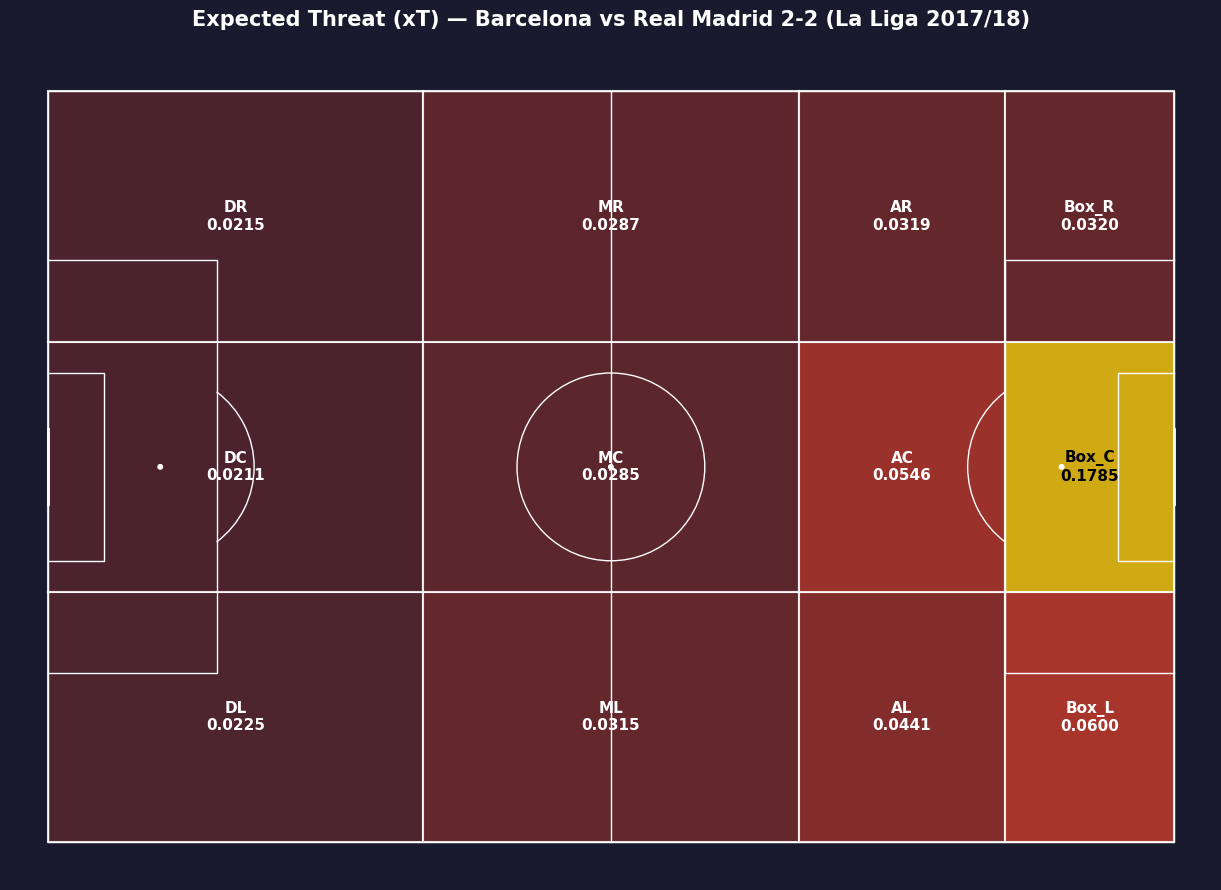

Plot saved as: xT_el_clasico.png


In [19]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap

# Zone rectangles in StatsBomb coordinates: (x, y, width, height)
ZONE_RECTS = {
    "DL":    (0,   53.33, 40, 26.67),
    "DC":    (0,   26.67, 40, 26.67),
    "DR":    (0,   0,     40, 26.67),
    "ML":    (40,  53.33, 40, 26.67),
    "MC":    (40,  26.67, 40, 26.67),
    "MR":    (40,  0,     40, 26.67),
    "AL":    (80,  53.33, 22, 26.67),
    "AC":    (80,  26.67, 22, 26.67),
    "AR":    (80,  0,     22, 26.67),
    "Box_L": (102, 53.33, 18, 26.67),
    "Box_C": (102, 26.67, 18, 26.67),
    "Box_R": (102, 0,     18, 26.67),
}

# Create the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', 
              line_color='#ffffff', line_zorder=2, linewidth=1)
fig, ax = pitch.draw(figsize=(14, 9))

# Color map: dark → red → yellow (low threat → high threat)
cmap = LinearSegmentedColormap.from_list("xT", ["#1a1a2e", "#c0392b", "#f39c12", "#f1c40f"])

# Map zone names to xT values
xT_dict = dict(zip(ZONES, xT.flatten()))
max_xT = max(xT.flatten())

# Draw each zone as a colored rectangle
for zone, (x, y, w, h) in ZONE_RECTS.items():
    val = xT_dict[zone]
    normalized = val / max_xT if max_xT > 0 else 0
    color = cmap(normalized)
    
    # Draw rectangle
    rect = plt.Rectangle((x, y), w, h, facecolor=color, 
                          edgecolor="white", linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    
    # Add zone label and xT value
    text_color = "white" if normalized < 0.55 else "black"
    ax.text(x + w/2, y + h/2, f"{zone}\n{val:.4f}",
            ha="center", va="center", fontsize=11, fontweight="bold",
            color=text_color, zorder=3)

# Title
ax.set_title("Expected Threat (xT) — Barcelona vs Real Madrid 2-2 (La Liga 2017/18)",
             fontsize=15, fontweight="bold", color="white", pad=20)

fig.patch.set_facecolor("#1a1a2e")
plt.tight_layout()
plt.savefig("xT_el_clasico.png", dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()

print("Plot saved as: xT_el_clasico.png")

## Summary & Next Steps

Our Markov chain xT model is complete for the Barcelona vs Real Madrid game. 
Let's recap what we built and what comes next.

**What we did:**
1. Loaded StatsBomb event data for El Clásico (match_id 9924)
2. Mapped every (x, y) coordinate to our 12-zone system
3. Classified every ball-moving event as a transition, goal, or loss
4. Built a transition count matrix → normalized to probabilities
5. Solved xT = (I − Q)⁻¹ · g to get the Expected Threat per zone
6. Visualized the result on a football pitch

**What this means for the project:**
- The only change needed for MTK VD FTC: instead of loading StatsBomb data, we use the `start_zone` / `end_zone` columns directly 
  (no coordinate mapping needed since the zones are already coded)
- The more matches we add, the more reliable the xT values become


In [21]:
summary = pd.DataFrame({
    "zone": ZONES,
    "zone_name": [
        "Defensive Left", "Defensive Center", "Defensive Right",
        "Middle Left", "Middle Center", "Middle Right",
        "Attacking Left", "Attacking Center", "Attacking Right",
        "Penalty Box Left", "Penalty Box Center", "Penalty Box Right"
    ],
    "xT": xT.flatten(),
    "direct_goal_prob": g.flatten(),
    "loss_prob": transition_probs["Loss"].values,
    "events_from_zone": row_totals.values
}).sort_values("xT", ascending=False)

print("=" * 80)
print("FINAL xT TABLE — Barcelona vs Real Madrid 2-2 (La Liga 2017/18)")
print("=" * 80)
print(f"\n{'Zone':<8} {'Name':<22} {'xT':>6} {'Goal%':>7} {'Loss%':>7} {'Events':>7}")
print("-" * 65)
for _, r in summary.iterrows():
    print(f"{r['zone']:<8} {r['zone_name']:<22} {r['xT']:>6.4f} {r['direct_goal_prob']:>6.1%} {r['loss_prob']:>6.1%} {int(r['events_from_zone']):>7}")


FINAL xT TABLE — Barcelona vs Real Madrid 2-2 (La Liga 2017/18)

Zone     Name                       xT   Goal%   Loss%  Events
-----------------------------------------------------------------
Box_C    Penalty Box Center     0.1785  12.5%  45.8%      24
Box_L    Penalty Box Left       0.0600   0.0%  29.2%      48
AC       Attacking Center       0.0546   1.0%  15.6%      96
AL       Attacking Left         0.0441   0.0%   3.9%     181
Box_R    Penalty Box Right      0.0320   0.0%  30.8%      52
AR       Attacking Right        0.0319   0.0%   9.0%     199
ML       Middle Left            0.0315   0.0%   3.8%     370
MR       Middle Right           0.0287   0.0%   3.9%     360
MC       Middle Center          0.0285   0.0%   6.6%     334
DL       Defensive Left         0.0225   0.0%   5.4%     149
DR       Defensive Right        0.0215   0.0%   7.7%     143
DC       Defensive Center       0.0211   0.0%   9.2%     152
